In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
A = np.array([[3,1],
              [1,3]])

print("Matrix A:\n",A)


Matrix A:
 [[3 1]
 [1 3]]


In [3]:
ATA = A.T @ A

print("A^T A =\n",ATA)




A^T A =
 [[10  6]
 [ 6 10]]


In [4]:
eigvals = np.array([16,4])

print("Eigenvalues (hard-coded):\n", eigvals)


Eigenvalues (hard-coded):
 [16  4]


In [5]:
V = (1/np.sqrt(2)) * np.array([[1,1],
                               [1,-1]])

print("Eigenvectors / V matrix:\n", V)


Eigenvectors / V matrix:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [6]:
singular_values = np.array([4,2])

print("Singular Values (hard-coded):\n", singular_values)


Singular Values (hard-coded):
 [4 2]


In [7]:
Sigma = np.array([[4,0],
                  [0,2]])

print("Sigma Matrix:\n", Sigma)


Sigma Matrix:
 [[4 0]
 [0 2]]


In [8]:
U = np.zeros((2,2))

for i in range(2):
    U[:,i] = (A @ V[:,i]) / singular_values[i]

print("U Matrix:\n", U)


U Matrix:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [9]:
VT = V.T

A_reconstructed = U @ Sigma @ VT

print("Reconstructed A:\n", A_reconstructed)


Reconstructed A:
 [[3. 1.]
 [1. 3.]]


In [10]:
import numpy as np

# Original Matrix
A = np.array([[3,1],
              [1,3]])

U = (1/np.sqrt(2)) * np.array([[1,1],
                               [1,-1]])

Sigma = np.array([[4,0],
                  [0,2]])

V = (1/np.sqrt(2)) * np.array([[1,1],
                               [1,-1]])

VT = V.T

print("Matrix A:\n", A)

print("\nU Matrix:\n", U)
print("\nSigma Matrix:\n", Sigma)
print("\nV^T Matrix:\n", VT)

# Multiply
result = U @ Sigma @ VT

print("\nU × Sigma × V^T =\n", result)


Matrix A:
 [[3 1]
 [1 3]]

U Matrix:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

Sigma Matrix:
 [[4 0]
 [0 2]]

V^T Matrix:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

U × Sigma × V^T =
 [[3. 1.]
 [1. 3.]]


In [11]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [13]:
data = pd.read_csv("train.csv")

print("Dataset Shape:",data.shape)
data.head()

Dataset Shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
labels = data.iloc[:,0]
pixels = data.iloc[:,1:]

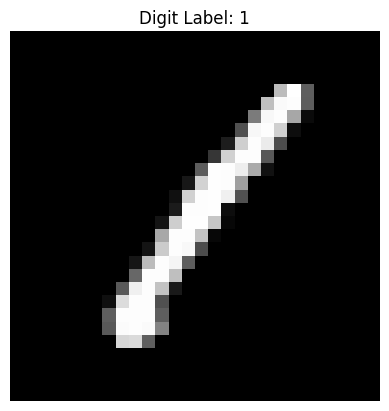

In [15]:
image = pixels.iloc[0].values.reshape(28,28)

plt.imshow(image,cmap='gray')
plt.title(f"Digit Label: {labels.iloc[0]}")
plt.axis("off")
plt.show()

In [16]:
U,S,VT = np.linalg.svd(image,full_matrices=False)

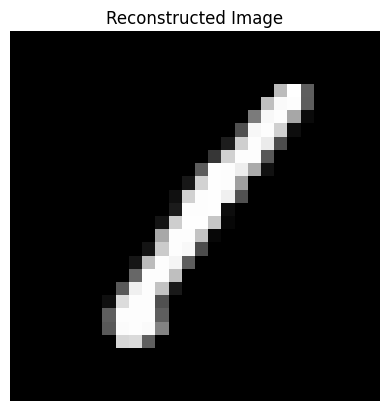

In [17]:
Sigma = np.diag(S)

reconstructed = U @ Sigma @ VT

plt.imshow(reconstructed,cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()

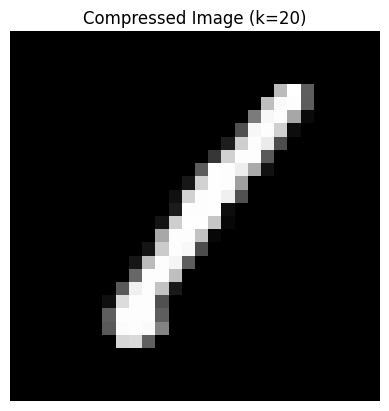

In [18]:
k = 20

U_k = U[:,:k]
S_k = np.diag(S[:k])
VT_k = VT[:k,:]

compressed = U_k @ S_k @ VT_k

plt.imshow(compressed,cmap='gray')
plt.title(f"Compressed Image (k={k})")
plt.axis("off")
plt.show()

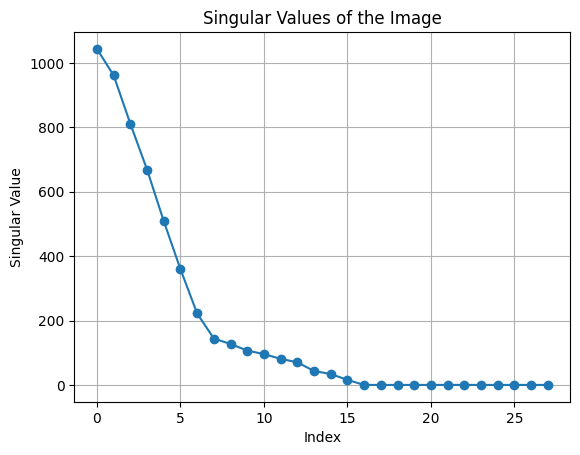

In [19]:
plt.plot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid()
plt.show()

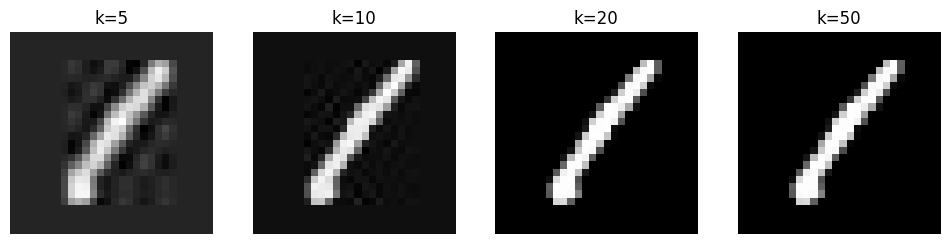

In [20]:
k_values = [5, 10, 20, 50]

plt.figure(figsize=(12,6))

for i,k in enumerate(k_values):
    U_k = U[:,:k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k,:]

    compressed = U_k @ S_k @ VT_k

    plt.subplot(1,len(k_values),i+1)
    plt.imshow(compressed,cmap='gray')
    plt.title(f"k={k}")
    plt.axis("off")

plt.show()

In [21]:
original_size = image.size
compressed_size = k*(1 + image.shape[0] + image.shape[1])

print("Original Size:", original_size)
print("Compressed Size (approx):", compressed_size)
print("Compression Ratio:", original_size/compressed_size)

Original Size: 784
Compressed Size (approx): 2850
Compression Ratio: 0.2750877192982456


In [22]:
error = np.linalg.norm(image - compressed)

print("Reconstruction Error:", error)

Reconstruction Error: 4.860994984757534e-12


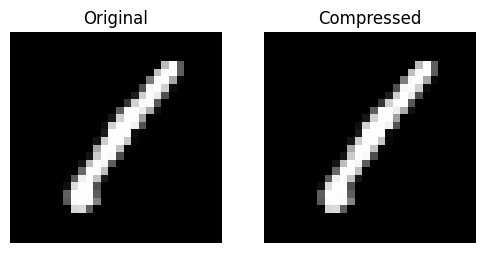

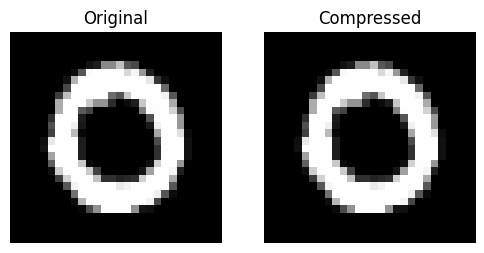

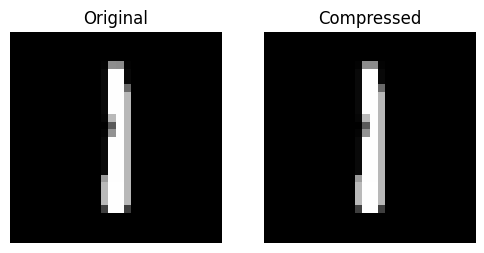

In [23]:
for i in range(3):
    img = pixels.iloc[i].values.reshape(28,28)

    U,S,VT = np.linalg.svd(img,full_matrices=False)

    k = 20
    compressed = U[:,:k] @ np.diag(S[:k]) @ VT[:k,:]

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(img,cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(compressed,cmap='gray')
    plt.title("Compressed")
    plt.axis("off")

    plt.show()